In [ ]:
# !pip install imbalanced-learn==0.11.0 --quiet

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score,accuracy_score
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import math

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
!ls /kaggle/input

e-commerce-customer-for-behavior-analysis


In [4]:
data = pd.read_csv("/kaggle/input/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_large.csv")
data.head()


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [5]:
print(f'Dataset contains {data.shape[0]} rows and {data.shape[1]} columns \n')
print(data.isnull().sum())


Dataset contains 250000 rows and 13 columns 

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [6]:
print(data.dtypes)
print('\n')
print(f'Duplicate rows: {data.duplicated().sum()}')


Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object


Duplicate rows: 0


In [7]:
data['Purchase Date'] = pd.to_datetime(data['Purchase Date'])
data['Year'] = data['Purchase Date'].dt.year
data['Month'] = data['Purchase Date'].dt.month
data['Day']=data['Purchase Date'].dt.day



categorical_column = data.select_dtypes(include=['object']).columns
for col in categorical_column:
    print(f"Unique Values in '{col}': {data[col].unique()}")


# One hot encoding
data = pd.get_dummies(data,columns=['Gender','Payment Method','Product Category'],drop_first=True)


data.update(data[['Returns']].fillna(data['Returns'].mode()[0]))


Unique Values in 'Product Category': ['Home' 'Electronics' 'Books' 'Clothing']
Unique Values in 'Payment Method': ['PayPal' 'Credit Card' 'Cash']
Unique Values in 'Customer Name': ['John Rivera' 'Lauren Johnson' 'Carol Allen' ... 'Gabriel Williams'
 'Barry Foster' 'Angela Norton']
Unique Values in 'Gender': ['Female' 'Male']


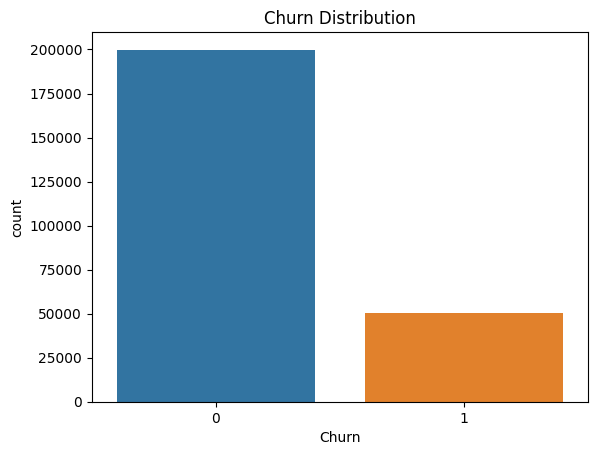

Churn
0    79.948
1    20.052
Name: count, dtype: float64


In [8]:
sns.countplot(x=data['Churn'])
plt.title('Churn Distribution')
plt.show()

print(((data['Churn'].value_counts())/len(data))*100)


In [9]:
numerical_cols =['Product Price', 'Quantity','Total Purchase Amount', 'Returns', 'Age', 'Year', 'Month', 'Day','Gender_Male', 'Payment Method_Credit Card', 'Payment Method_PayPal', 'Product Category_Clothing','Product Category_Electronics', 'Product Category_Home']
data.columns


Index(['Customer ID', 'Purchase Date', 'Product Price', 'Quantity',
       'Total Purchase Amount', 'Customer Age', 'Returns', 'Customer Name',
       'Age', 'Churn', 'Year', 'Month', 'Day', 'Gender_Male',
       'Payment Method_Credit Card', 'Payment Method_PayPal',
       'Product Category_Clothing', 'Product Category_Electronics',
       'Product Category_Home'],
      dtype='object')

In [10]:
df=data

In [11]:
# Grouping by Customer ID to create sequences
seq_length = 10
churn_offset = 1 #when do we consider the customer seq as churn seq
features = numerical_cols 

def pad_sequence(sequence, seq_length, pad_value=0):
    """Pad a sequence with pad_value if it's shorter than seq_length"""
    if len(sequence) >= seq_length:
        return sequence
    padding = np.array([pad_value] * (seq_length - len(sequence)))
    return np.concatenate([sequence, padding])

sequences = []
labels = []

customer_ids = df['Customer ID'].unique()
for cid in customer_ids:
    customer_data = df[df['Customer ID'] == cid].sort_values(by='Purchase Date')
    for i in range(max(1,len(customer_data)-seq_length+1)):
        seq = customer_data.iloc[i:min(i+seq_length, len(customer_data))][features].values
        if len(seq) < seq_length:
            pad_shape = (seq_length - len(seq), len(features))
            padding = np.zeros(pad_shape)
            seq = np.vstack([seq, padding])
        if i + seq_length < len(customer_data) - churn_offset:
            label = 0
        else:
            label = customer_data.iloc[min(i+seq_length-1, len(customer_data)-1)]['Churn']
        sequences.append(seq)
        labels.append(label)

X = np.array(sequences)
y = np.array(labels)

print(X.shape, y.shape)





(50792, 10, 14) (50792,)


In [12]:
# Drop original purchase date
data.drop(columns=['Purchase Date'],inplace=True)
# Drop customer_Id and customer_name
data.drop(columns=['Customer Name','Customer ID'],inplace=True)


In [13]:
X_reshaped = X.reshape(X.shape[0], -1)  # (50792, 140)
X = X_reshaped


In [14]:
X.shape

(50792, 140)

In [15]:
from imblearn.over_sampling import SMOTE 

x=X

smote = SMOTE(random_state=42)
x_resampled,y_resampled = smote.fit_resample(x,y)

# Check the balance of the resampled data
print(f"Original class distribution:\n{y.sum()}")
print(f"Resampled class distribution:\n{y.sum()}")


Original class distribution:
10060
Resampled class distribution:
10060


In [16]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
x_resampled = scaler.fit_transform(x_resampled)



joblib.dump(scaler, "scaler.pkl")



['scaler.pkl']

In [17]:
x_resampled.shape

(81464, 140)

In [18]:
print(x_resampled)

[[ 1.18573331 -1.51796391 -0.27449683 ... -0.11480453 -0.12065935
  -0.11560789]
 [-1.81799956 -0.76081066 -0.39364096 ... -0.11480453 -0.12065935
  -0.11560789]
 [ 0.19697336 -1.51796391  0.75224517 ... -0.11480453 -0.12065935
  -0.11560789]
 ...
 [ 1.0471951  -0.09490552  0.65375256 ... -0.11480453 -0.12065935
  -0.11560789]
 [-1.43438932  0.75349584  1.38894116 ... -0.11480453 -0.12065935
  -0.11560789]
 [-1.70391526  0.47600732 -1.65909595 ... -0.11480453 -0.12065935
  -0.11560789]]


In [19]:
x_resampled = x_resampled.reshape(-1, seq_length, len(numerical_cols))

In [20]:
x_resampled.shape


(81464, 10, 14)

In [21]:
from sklearn.model_selection import train_test_split

X_train, x_temp, y_train, y_temp = train_test_split(x_resampled,y_resampled,test_size=0.3,random_state=42)
X_val, X_test,y_val,y_test = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42)


# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

# Check the size of each
print(f'Training Set: {X_train.shape[0]} samples')
print(f'Validation Set: {X_val.shape[0]} samples')
print(f'Testing Set: {X_test.shape[0]} samples')


Training Set: 57024 samples
Validation Set: 12220 samples
Testing Set: 12220 samples


In [22]:
X_train.shape


(57024, 10, 14)

In [23]:



# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerLayer, self).__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout)
        
        # Feed-forward network
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        
    def forward(self, src):
        # src shape: (seq_len, batch_size, d_model)
        
        # Self-attention with residual connection
        src2 = self.norm1(src)
        attn_output, _ = self.self_attn(src2, src2, src2)
        src = src + (attn_output)
        
        # Feed-forward with residual connection
        src2 = self.norm2(src)
        src2 = self.linear2((F.relu(self.linear1(src2))))
        src = src + (src2)
        
        return src

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, num_heads, d_ff, num_layers, output_size):
        super(TransformerModel, self).__init__()
        
        # Project input to model dimension
        self.embedding = nn.Linear(input_size, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerLayer(d_model, num_heads, d_ff) 
            for _ in range(num_layers)
        ])
        
        # Output layer
        self.fc = nn.Linear(d_model, d_model//2)
        self.output_layer = nn.Linear(d_model//2, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        
        # Reorder to (seq_len, batch_size, input_size)
        x = x.transpose(0, 1)
        
        # Project to d_model
        x = self.embedding(x)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Pass through transformer layers
        for layer in self.transformer_layers:
            x = layer(x)
        
        # Get last time step (many-to-one)
        x = x[-1, :, :]  # (batch_size, d_model)
        
        # Output layer
        x=self.fc(x)
        output = self.output_layer(x)
        return torch.sigmoid(output)

print("ok")


ok


In [25]:
def initialize_transformer_weights(model):
    # Initialize linear layers
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
                
        # Initialize multi-head attention
        elif isinstance(m, nn.MultiheadAttention):
            nn.init.xavier_uniform_(m.in_proj_weight)
            nn.init.xavier_uniform_(m.out_proj.weight)
            if m.in_proj_bias is not None:
                nn.init.constant_(m.in_proj_bias, 0)
                nn.init.constant_(m.out_proj.bias, 0)
                
        # Initialize layer norms
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
            
    print("Model weights initialized")


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# Check for CUDA availability and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
input_size = X_train.shape[2]  
d_model = 128
num_heads = 8
d_ff = 218
num_layers = 2
output_size = 1
batch_size = 128
learning_rate = 0.00001
num_epochs = 400
dropout = 0.1
patience = 23

# Initialize model, loss, and optimizer
# del model
model = TransformerModel(input_size, d_model, num_heads, d_ff, num_layers, output_size).to(device)
initialize_transformer_weights(model)  # <-- Initialize here
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.7, 0.99), weight_decay=1e-6)

# Create DataLoaders - keep data on CPU and move to GPU in batches
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                             torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                           torch.tensor(y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.float32))

# Only pin memory if we're using CUDA
pin_memory = device.type != 'cuda'
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        start_time = time.time()
        train_all_preds = []
        train_all_targets = []

        # Training phase
        for batch_idx, (data, target) in enumerate(train_loader):
            # Move data to GPU
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            # شيك عهي
            
            # Forward pass
            output = model(data)
            loss = criterion(output.squeeze(), target)
            
            # Backward pass and optimize
            loss.backward()
            epoch_train_loss += loss.item()
            train_preds = (output > 0.5).float()
            train_all_preds.extend(train_preds.detach().cpu().numpy())
            train_all_targets.extend(target.detach().cpu().numpy())

            optimizer.step()
            
            
            # # Print progress
            # if batch_idx % 100 == 0:
            #     print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        # Calculate average training loss
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_all_preds = np.array(train_all_preds)
        train_all_targets = np.array(train_all_targets)
        train_accuracy = accuracy_score(train_all_targets, train_all_preds)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output.squeeze(), target).item()
                
                # Store predictions and targets for metrics
                preds = (output > 0.5).float()
                all_preds.extend(preds.cpu().numpy())  # Move back to CPU for sklearn
                all_targets.extend(target.cpu().numpy())
        
        avg_val_loss = val_loss/len(val_loader)
        val_losses.append(avg_val_loss)

      


        
        # Calculate metrics
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        accuracy = accuracy_score(all_targets, all_preds)
        precision = precision_score(all_targets, all_preds)
        recall = recall_score(all_targets, all_preds)
        f1 = f1_score(all_targets, all_preds)
        val_accuracies.append(accuracy) 

        
        # Print epoch statistics
        epoch_time = time.time() - start_time
        
        print(f'\nEpoch {epoch+1}/{num_epochs} - {epoch_time:.2f}s')
        print(f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
        print(f'Val Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print('Saved new best model')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

        
        print('-' * 50)
    
    return train_losses, val_losses,val_accuracies,train_accuracies

# Train the model
train_losses, val_losses,val_accuracies,train_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)


Using device: cuda
Model weights initialized

Epoch 1/400 - 4.65s
Train Loss: 0.7587 | Val Loss: 0.6928
Val Accuracy: 0.5443 | Precision: 0.5359 | Recall: 0.5983 | F1: 0.5654
Saved new best model
--------------------------------------------------

Epoch 2/400 - 3.43s
Train Loss: 0.6893 | Val Loss: 0.6770
Val Accuracy: 0.5829 | Precision: 0.5735 | Recall: 0.6175 | F1: 0.5947
Saved new best model
--------------------------------------------------

Epoch 3/400 - 3.47s
Train Loss: 0.6749 | Val Loss: 0.6649
Val Accuracy: 0.6128 | Precision: 0.6062 | Recall: 0.6238 | F1: 0.6148
Saved new best model
--------------------------------------------------

Epoch 4/400 - 3.46s
Train Loss: 0.6614 | Val Loss: 0.6498
Val Accuracy: 0.6273 | Precision: 0.6072 | Recall: 0.7019 | F1: 0.6511
Saved new best model
--------------------------------------------------

Epoch 5/400 - 3.48s
Train Loss: 0.6454 | Val Loss: 0.6327
Val Accuracy: 0.6556 | Precision: 0.6488 | Recall: 0.6649 | F1: 0.6568
Saved new best mo

In [27]:
# Evaluate on test set
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            # Store predictions and probabilities
            preds = (output > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(output.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_probs)
    
    print('\nTest Set Evaluation:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')
    return all_preds,all_probs,all_targets
# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
all_preds,all_probs,all_targets=evaluate_model(model, test_loader)


Test Set Evaluation:
Accuracy: 0.8446
Precision: 0.9781
Recall: 0.7044
F1 Score: 0.8190
ROC AUC: 0.8740


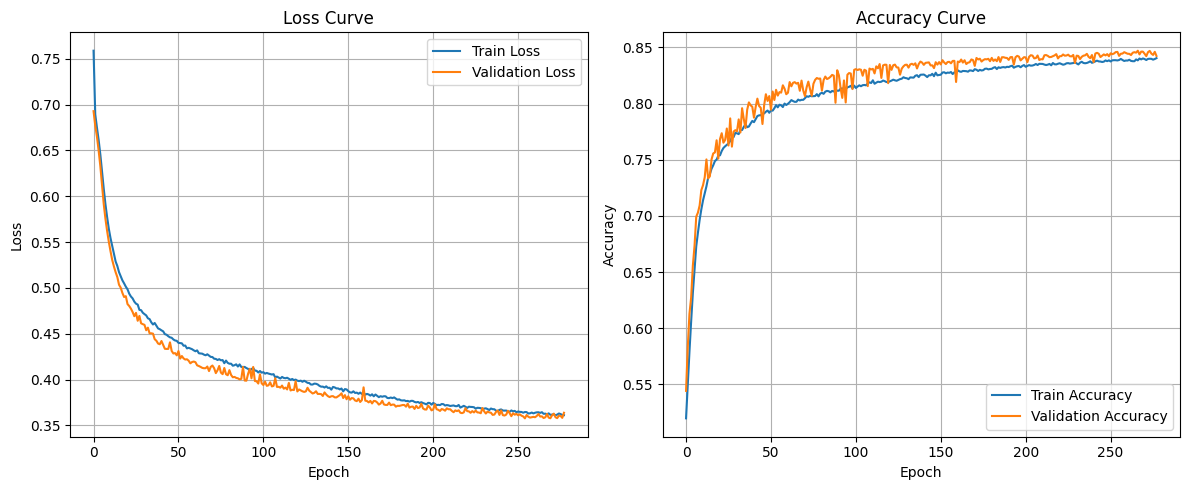

In [28]:


# Plot Loss Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='')
plt.plot(val_losses, label='Validation Loss', marker='')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='')
plt.plot(val_accuracies, label='Validation Accuracy', marker='')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
torch.save(model.state_dict(), '/kaggle/working/my_model.pth')


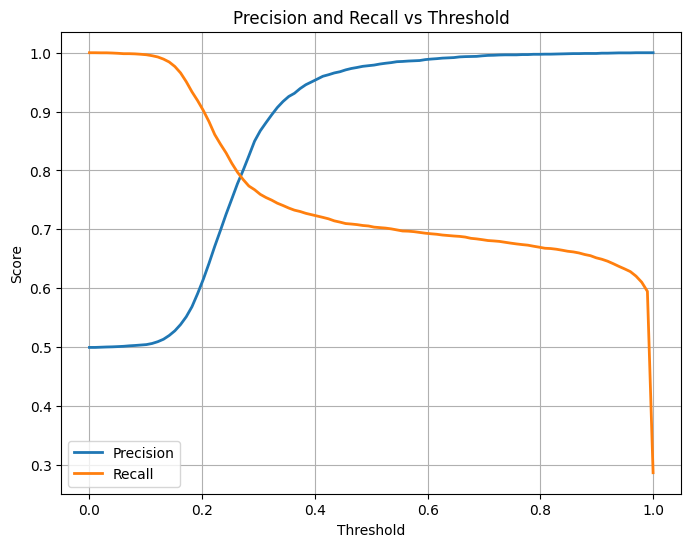

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

def plot_precision_recall_vs_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    precisions = []
    recalls = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(float)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions, label="Precision", linewidth=2)
    plt.plot(thresholds, recalls, label="Recall", linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision and Recall vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

# After evaluating the model and collecting all_probs and all_targets
# make sure these are available as numpy arrays:
# all_probs = np.array(all_probs)
# all_targets = np.array(all_targets)

plot_precision_recall_vs_threshold(all_targets, all_probs)
